-------------------------------
-------------------------------
# Proyecto 2 - Minería de Datos (CC3074)
* Dulce Ambrosio - 231143
* Daniel Chet - 231177
* Javier Linares - 231435
* Cristian Túnchez - 231359

-------------------------------
-------------------------------

In [ ]:
# ======================
# Importación de librerías
# ======================
# pandas / numpy: manipulación numérica y de tablas
# matplotlib / seaborn: visualización exploratoria (EDA)

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética (tema de Seaborn)
sns.set(style="whitegrid")

In [ ]:
# ======================
# Carga inicial del dataset
# ======================

# Cargar el dataset
df = pd.read_csv("Datos.csv")

# Vista rápida, valida que se cargó correctamente y revisa columnas/valores iniciales
df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [ ]:
# ======================
# 3) Estructura del dataset
# ======================
# df.info() permite revisar:
# - número de filas/columnas
# - tipos de datos por columna
# - conteo de valores no nulos (detecta datos faltantes)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Sample code number           683 non-null    int64
 1   Clump Thickness              683 non-null    int64
 2   Uniformity of Cell Size      683 non-null    int64
 3   Uniformity of Cell Shape     683 non-null    int64
 4   Marginal Adhesion            683 non-null    int64
 5   Single Epithelial Cell Size  683 non-null    int64
 6   Bare Nuclei                  683 non-null    int64
 7   Bland Chromatin              683 non-null    int64
 8   Normal Nucleoli              683 non-null    int64
 9   Mitoses                      683 non-null    int64
 10  Class                        683 non-null    int64
dtypes: int64(11)
memory usage: 58.8 KB


In [11]:
# ======================
# 4) Estadísticas descriptivas
# ======================
# describe() resume variables numéricas: media, desviación, percentiles, etc.
# Sirve para detectar rangos anómalos o escalas muy diferentes.
df.describe()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.830000e+02,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,1.076720e+06,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,6.206440e+05,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,6.337500e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.776170e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171795e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238705e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [ ]:
# ======================
# 5) Inspección de valores en 'Bare Nuclei'
# ======================
# Revisar unique() ayuda a confirmar si existen valores no numéricos.
df['Bare Nuclei'].unique()

array([ 1, 10,  2,  4,  3,  9,  7,  5,  8,  6])

In [ ]:
# ======================
# 6) Limpieza: convertir 'Bare Nuclei' a numérico
# ======================
# errors='coerce' convierte valores inválidos a NaN.
df['Bare Nuclei'] = pd.to_numeric(df['Bare Nuclei'], errors='coerce')

In [ ]:
# ======================
# 7) Diagnóstico de valores faltantes
# ======================
# isnull().sum() muestra cuántos NaN hay por columna.
df.isnull().sum()

Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

In [ ]:
# ======================
# Tratamiento de faltantes
# ======================
# eliminar filas con cualquier NaN.
df = df.dropna()

In [ ]:
# confirmar que ya no hay valores nulos después de dropna()
df.isnull().sum()

Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

In [ ]:
# ======================
# Variable objetivo (Class)
# ======================
# value_counts() permite revisar el balance de clases (posible desbalance).
df['Class'].value_counts()

Class
2    444
4    239
Name: count, dtype: int64

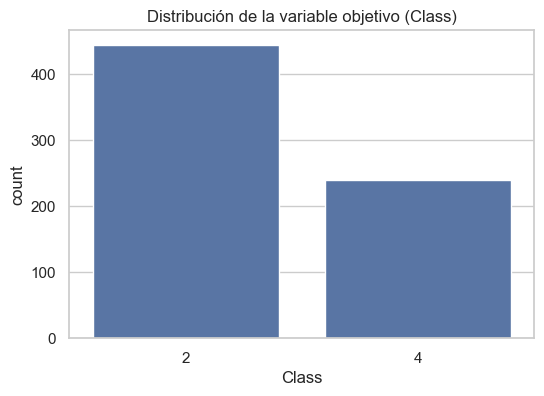

In [ ]:
# ======================
#  Visualización: distribución de la variable objetivo
# ======================
# countplot muestra cuántos ejemplos hay por clase.
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Distribución de la variable objetivo (Class)")
plt.show()

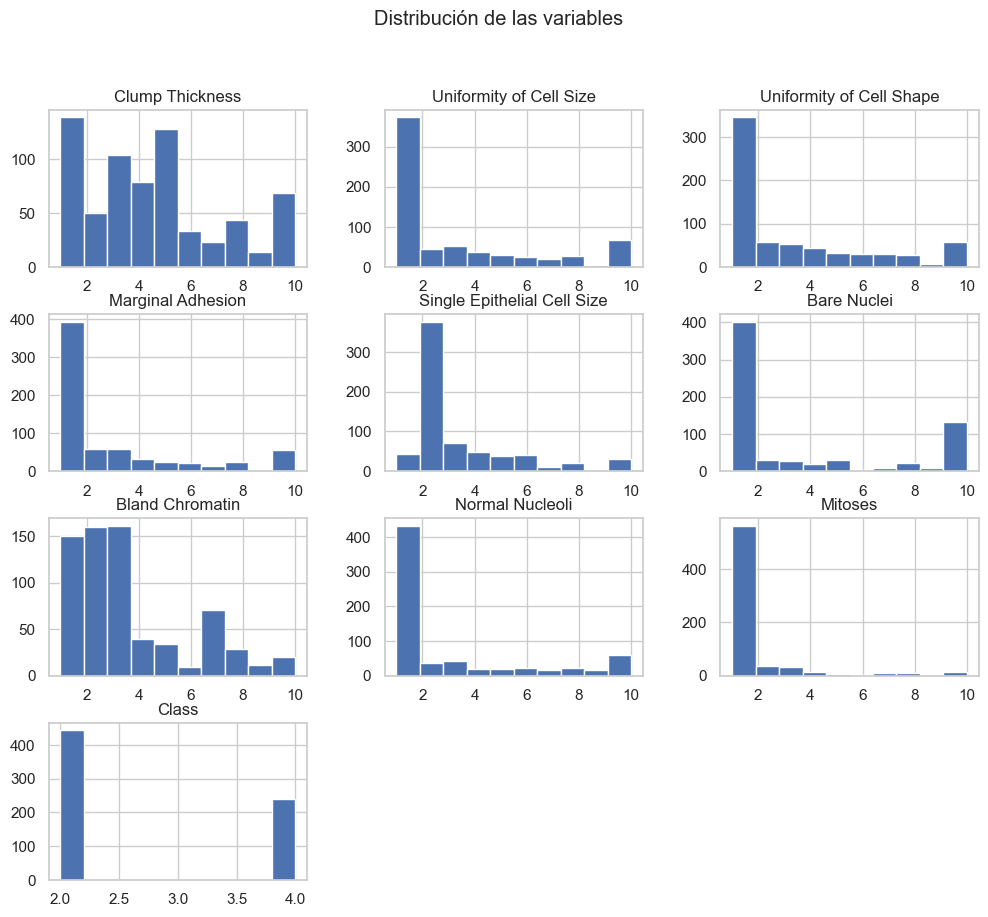

In [ ]:
# ======================
# Visualización: histogramas de variables
# ======================
df = df.drop(columns=['Sample code number'], errors='ignore')

df.hist(figsize=(12,10))
plt.suptitle("Distribución de las variables")
plt.show()

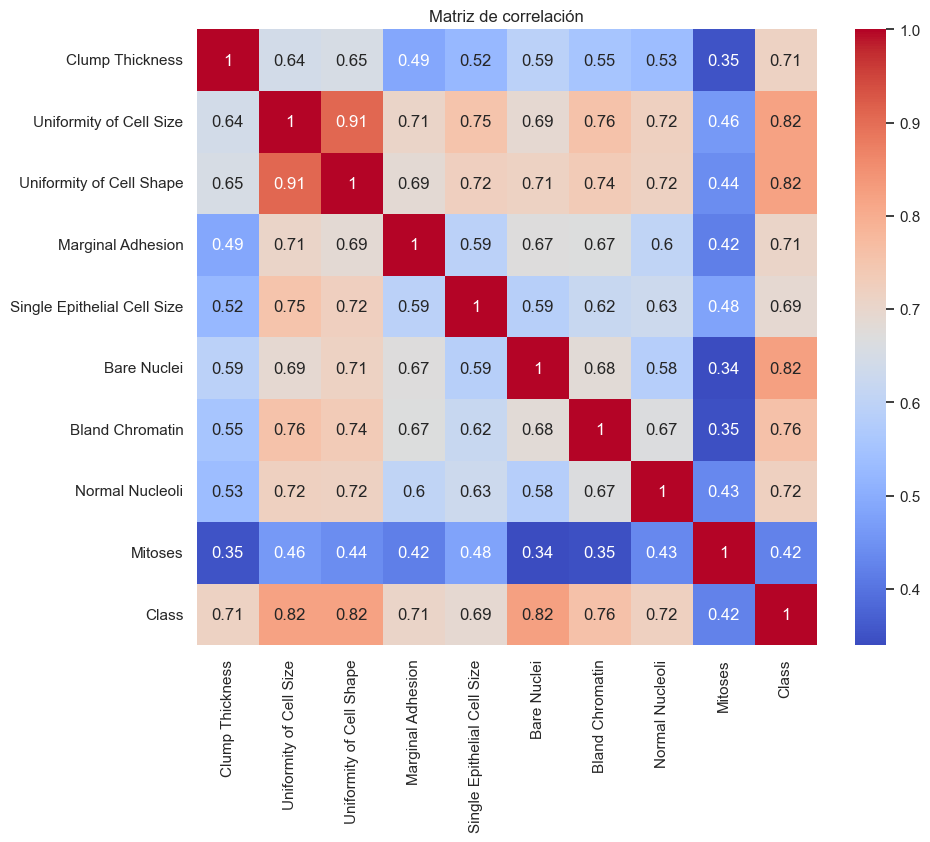

In [ ]:
# ======================
# Visualización: matriz de correlación
# ======================
# Mide relación lineal entre variables numéricas.
# Valores cercanos a 1/-1 indican fuerte correlación positiva/negativa.
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

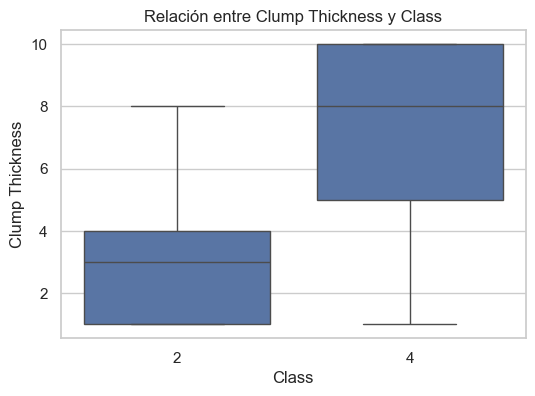

In [ ]:
# ======================
# Visualización: 

# ======================
# Una gráfica de caja compara medianas, dispersión y outliers entre clases.
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Clump Thickness', data=df)
plt.title("Relación entre Clump Thickness y Class")
plt.show()

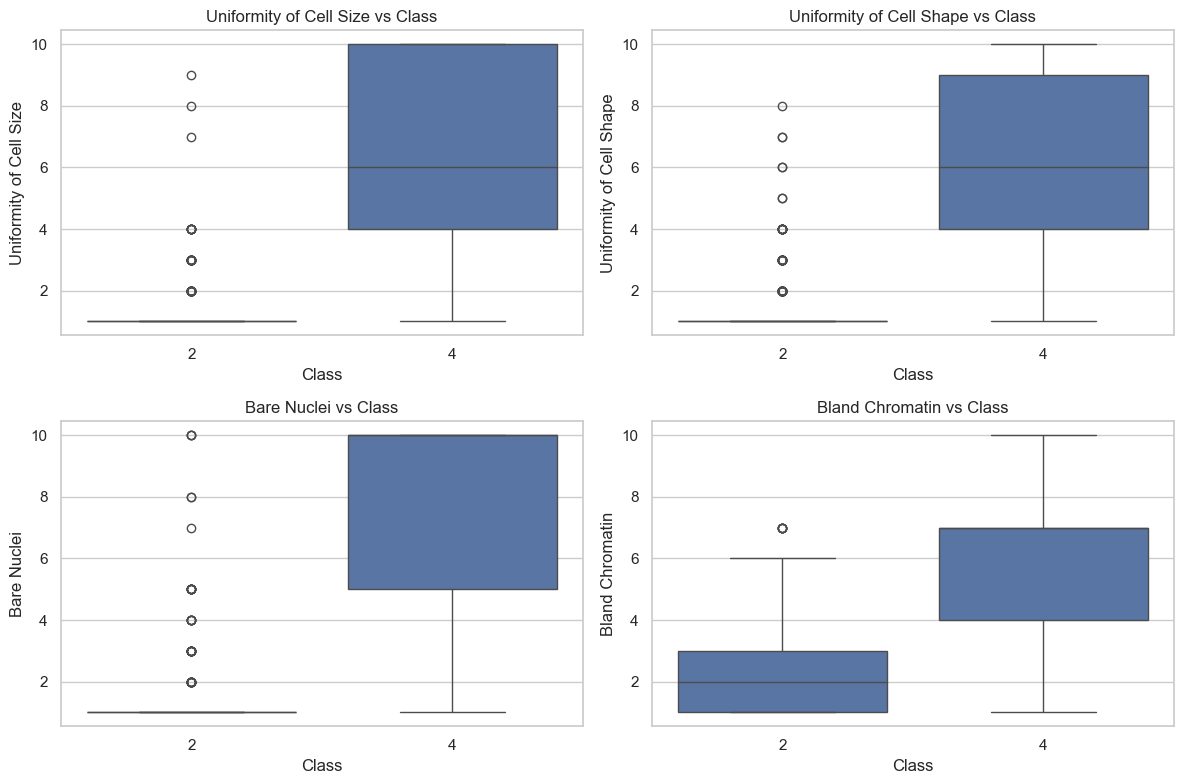

In [ ]:
# ======================
# Visualización: boxplots para múltiples variables (en una sola figura)
# ======================
# Se repite el análisis anterior para varias variables relevantes, para observar
# qué tan separables son las distribuciones por clase.
variables = [
    'Uniformity of Cell Size',
    'Uniformity of Cell Shape',
    'Bare Nuclei',
    'Bland Chromatin'
 ]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, var in zip(axes, variables):
    sns.boxplot(x='Class', y=var, data=df, ax=ax)
    ax.set_title(f"{var} vs Class")
    ax.set_xlabel('Class')
    ax.set_ylabel(var)

plt.tight_layout()
plt.show()